In [10]:
import ase 
from ase import io
from ase.visualize import view
from pathlib import Path
import matplotlib.pyplot as plt

import sys
sys.path.append("/mmhome/boittier/home/mmml")

import mmml
import ase
import numpy as np
from ase import io
from ase.constraints import FixInternals
from ase.optimize import BFGS
from mmml.models.EF.ase_calc_EF import AseCalculatorEF

from mmml.interfaces.chemcoordInterface.interface import patch_chemcoord_for_pandas3

patch_chemcoord_for_pandas3()

import ase
from ase import io as ase_io
from ase.visualize import view
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns


import chemcoord as cc

In [54]:
import numpy as np


def _best_fit_plane(coords):
    coords = np.asarray(coords, dtype=float)
    centroid = coords.mean(axis=0)
    X = coords - centroid
    _, _, vh = np.linalg.svd(X, full_matrices=False)
    normal = vh[-1]
    normal /= np.linalg.norm(normal)
    z = X @ normal
    return centroid, normal, z


def _cp_single(R, ring_idx, degrees=False):
    R = np.asarray(R, dtype=float)
    ring = R[ring_idx]
    n = len(ring_idx)

    centroid, normal, z = _best_fit_plane(ring)
    j = np.arange(n)

    if n == 5:
        c = np.cos(4.0 * np.pi * j / 5.0)
        s = np.sin(4.0 * np.pi * j / 5.0)

        A = np.sqrt(2.0 / 5.0) * np.sum(z * c)
        B = -np.sqrt(2.0 / 5.0) * np.sum(z * s)

        q = np.hypot(A, B)
        P = np.arctan2(B, A)

        if degrees:
            P = np.rad2deg(P)

        return {
            "q": q,
            "P": P,
            "z": z,
            "centroid": centroid,
            "normal": normal,
        }

    elif n == 6:
        c = np.cos(4.0 * np.pi * j / 6.0)
        s = np.sin(4.0 * np.pi * j / 6.0)

        A = np.sqrt(2.0 / 6.0) * np.sum(z * c)
        B = -np.sqrt(2.0 / 6.0) * np.sum(z * s)

        q2 = np.hypot(A, B)
        phi = np.arctan2(B, A)
        q3 = np.sqrt(1.0 / 6.0) * np.sum(((-1.0) ** j) * z)

        Q = np.hypot(q2, q3)
        theta = np.arctan2(q2, q3)

        if degrees:
            phi = np.rad2deg(phi)
            theta = np.rad2deg(theta)

        return {
            "q2": q2,
            "phi": phi,
            "q3": q3,
            "Q": Q,
            "theta": theta,
            "z": z,
            "centroid": centroid,
            "normal": normal,
        }

    else:
        raise ValueError("Only 5- or 6-membered rings are supported")


def cp_from_R(R, ring_idx, degrees=False):
    """
    Accepts:
        R.shape == (N, 3)     -> returns dict for one structure
        R.shape == (M, N, 3)  -> returns dict of arrays for M structures
    """
    R = np.asarray(R, dtype=float)

    if R.ndim == 2:
        return _cp_single(R, ring_idx, degrees=degrees)

    elif R.ndim == 3:
        results = [_cp_single(r, ring_idx, degrees=degrees) for r in R]
        keys = results[0].keys()
        return {k: np.array([res[k] for res in results]) for k in keys}

    else:
        raise ValueError(f"R must have shape (N,3) or (M,N,3), got {R.shape}")

In [11]:
samples_dir = "qP_samples"
listed_files = list(Path(samples_dir).glob("*.xyz"))

In [203]:
mol = ase.io.read(listed_files[0])
mol

Atoms(symbols='CH2CH2CH2CH2CH2', pbc=False)

In [204]:
CONFIG= "/mmhome/boittier/home/ckpts/ring_ef2_ptT_run2/config-66b8e895-abc4-4ae5-9c26-3e09c67126a2.json"
PARAMS = "/mmhome/boittier/home/ckpts/ring_ef2_ptT_run2/params-66b8e895-abc4-4ae5-9c26-3e09c67126a2.json"
EF = np.array([0,0,0])

In [205]:
calc = AseCalculatorEF(
    PARAMS,
    config_path=CONFIG,
    electric_field=EF,  # optional default field (model input units)
    field_scale=100,  # E_physical [au] = E_input * field_scale
)
print(calc)

In [206]:
mol.calc = calc

In [207]:
view(mol, viewer="x3d")

In [208]:
mol.get_potential_energy()

-66.2966537475586

In [209]:
mol.get_forces()

array([[ 0.9932517 ,  0.8865849 ,  0.07258967],
       [ 0.20862184, -0.14216089,  0.14752984],
       [-0.03267074,  0.2913809 , -0.30569   ],
       [ 0.5932753 , -0.89258087, -2.5829642 ],
       [ 1.2746385 ,  0.848346  , -0.47598985],
       [-1.1223464 , -0.1354171 ,  0.22368516],
       [-1.9232519 ,  1.9172432 ,  3.1100588 ],
       [-0.9678935 , -0.67497677,  0.22340524],
       [ 0.3128277 ,  0.2429012 , -0.5055672 ],
       [ 0.9896005 , -2.4004133 , -2.5558417 ],
       [ 0.3149755 ,  0.2212985 ,  0.42028493],
       [-0.95867497, -0.71718735, -0.11853904],
       [-0.07518655,  0.7301011 ,  2.4666119 ],
       [-0.4856646 , -0.70664096, -0.12277338],
       [ 0.87849724,  0.531521  ,  0.00319946]], dtype=float32)

In [210]:
mol.get_dipole_moment()

array([0.01100395, 0.00446722, 0.00130817], dtype=float32)

In [211]:
# set up optimizer
opt = BFGS(
    mol,
    trajectory="opt_bfgs.traj",   # optional: saves optimization path
    logfile="-",                  # prints progress in notebook
    maxstep=0.04,                 # conservative step size (A)
)
# run until converged
opt.run(fmax=0.003, steps=1000)
print("Converged geometry:")
print(mol.get_positions())
print("Final energy (eV):", mol.get_potential_energy())
print("Final max |F| (eV/A):", np.max(np.abs(mol.get_forces())))

      Step     Time          Energy          fmax
BFGS:    0 14:13:06      -66.296654        4.128824
BFGS:    1 14:13:06      -66.717751        1.785958
BFGS:    2 14:13:06      -67.077248        2.021421
BFGS:    3 14:13:06      -67.342079        1.627621
BFGS:    4 14:13:06      -67.538170        1.112920
BFGS:    5 14:13:06      -67.680847        0.885793
BFGS:    6 14:13:06      -67.766472        0.591658
BFGS:    7 14:13:06      -67.824402        0.671662
BFGS:    8 14:13:06      -67.857590        0.697305
BFGS:    9 14:13:06      -67.897423        0.493754
BFGS:   10 14:13:06      -67.922928        0.213078
BFGS:   11 14:13:06      -67.917732        0.141465
BFGS:   12 14:13:06      -67.928322        0.143897
BFGS:   13 14:13:06      -67.926315        0.116105
BFGS:   14 14:13:06      -67.924622        0.129147
BFGS:   15 14:13:06      -67.925735        0.136201
BFGS:   16 14:13:06      -67.928986        0.158000
BFGS:   17 14:13:06      -67.938759        0.234662
BFGS:   18 14:

In [211]:
# --- ASE NVE (Velocity Verlet): minimal example ---
import numpy as np
from ase import Atoms, units
from ase.calculators.lj import LennardJones
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation

from pathlib import Path
from ase.io.trajectory import Trajectory

rng = np.random.default_rng(7)
temperature_K = 300.0
MaxwellBoltzmannDistribution(mol, temperature_K=temperature_K, rng=rng)
# Optional: zero net drift / angular momentum (recommended for finite clusters & NVE)
Stationary(mol)
ZeroRotation(mol)
dt_fs = 0.5
dyn = VelocityVerlet(mol, timestep=dt_fs * units.fs)
E0 = mol.get_potential_energy() + mol.get_kinetic_energy()
print(f"initial E_tot (eV) ≈ {E0:.6f}")

NSTEP = 500_000
STEPSIZE = 1000

traj_path = Path("nve_test.traj")  # change as you like
with Trajectory(traj_path, mode="w") as traj:
    traj.write(mol)  # frame 0
    for step in range(0, NSTEP, STEPSIZE):
        if step > 0:
            dyn.run(STEPSIZE)
        traj.write(mol)
        #print(step, "frames written →", traj_path)
        Epot = mol.get_potential_energy()
        Ekin = mol.get_kinetic_energy()
        T = mol.get_temperature()
        print(f"step={step:4d}  E_pot={Epot:+.5f}  E_kin={Ekin:+.5f}  E_tot={Epot+Ekin:+.5f}  T(K)≈{T:.1f}")


# for step in range(0, NSTEP, log_every):
#     if step > 0:
#         dyn.run(log_every)
#     Epot = mol.get_potential_energy()
#     Ekin = mol.get_kinetic_energy()
#     T = mol.get_temperature()
#     print(f"step={step:4d}  E_pot={Epot:+.5f}  E_kin={Ekin:+.5f}  E_tot={Epot+Ekin:+.5f}  T(K)≈{T:.1f}")

initial E_tot (eV) ≈ -67.556829
step=   0  E_pot=-68.02071  E_kin=+0.46388  E_tot=-67.55683  T(K)≈239.3
step=1000  E_pot=-67.80231  E_kin=+0.25322  E_tot=-67.54908  T(K)≈130.6
step=2000  E_pot=-67.81488  E_kin=+0.26056  E_tot=-67.55432  T(K)≈134.4
step=3000  E_pot=-67.83846  E_kin=+0.28249  E_tot=-67.55597  T(K)≈145.7
step=4000  E_pot=-67.83644  E_kin=+0.28290  E_tot=-67.55354  T(K)≈145.9
step=5000  E_pot=-67.82487  E_kin=+0.27325  E_tot=-67.55163  T(K)≈140.9
step=6000  E_pot=-67.81004  E_kin=+0.26242  E_tot=-67.54762  T(K)≈135.3
step=7000  E_pot=-67.84245  E_kin=+0.29230  E_tot=-67.55015  T(K)≈150.8
step=8000  E_pot=-67.81551  E_kin=+0.26391  E_tot=-67.55159  T(K)≈136.1
step=9000  E_pot=-67.76659  E_kin=+0.20830  E_tot=-67.55830  T(K)≈107.4
step=10000  E_pot=-67.84099  E_kin=+0.29026  E_tot=-67.55073  T(K)≈149.7
step=11000  E_pot=-67.81147  E_kin=+0.25927  E_tot=-67.55220  T(K)≈133.7
step=12000  E_pot=-67.85001  E_kin=+0.29456  E_tot=-67.55544  T(K)≈151.9
step=13000  E_pot=-67.73055  


KeyboardInterrupt



KeyboardInterrupt: 

In [ ]:
from ase.io import read
from ase.io.trajectory import Trajectory
frames = read("nve_test.traj", ":")

In [ ]:
len(frames)

In [ ]:
view(frames[-1], viewer="x3d")

In [194]:
view(mol, viewer="x3d")

In [195]:
mol.calc.electric_field

Array([0., 0., 0.], dtype=float32)

In [196]:
cps = []
Es = []
for _ in frames:

    
    R = _.get_positions()
    ring_idx = [0, 3, 6, 9, 12]  # your case (5-ring)
    
    cp = cp_from_R(R, ring_idx, degrees=True)
    cps.append(cp)
    Es.append(_.get_potential_energy())


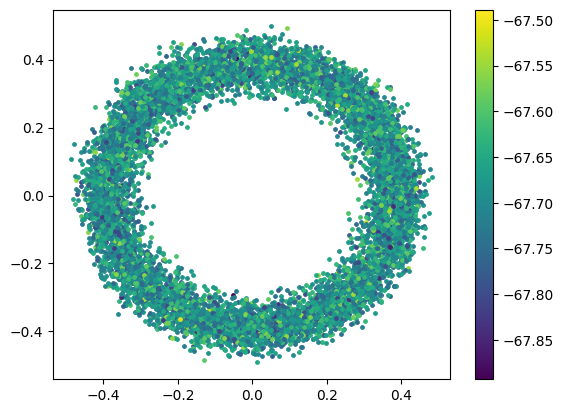

In [197]:
cps_, Es_ = [], []
for cp, E in zip(cps, Es):
    s = plt.scatter(cp["q"] * np.cos(cp["P"]), cp["q"] * np.sin(cp["P"]), s=6.0, c=E, vmin=min(Es), vmax=max(Es))
    cps_.append((cp["q"] * np.cos(cp["P"]), cp["q"] * np.sin(cp["P"])))
plt.colorbar(s)

In [198]:
# N = 10
# plt.plot(cps_[:N,0], cps_[:N,1], alpha=.1)
# plt.scatter(cps_[:N,0], cps_[:N,1], c=range(N), cmap="Reds")

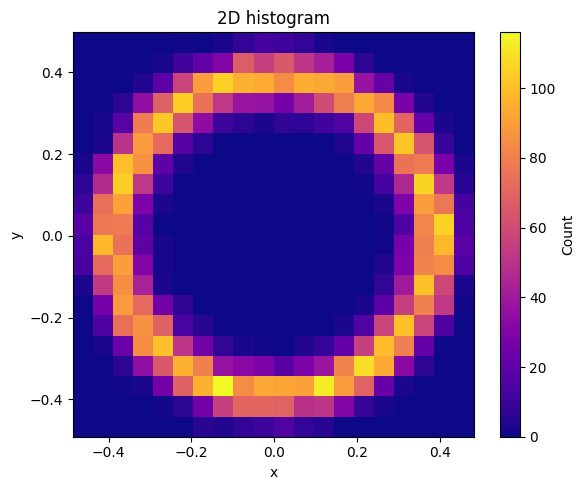

In [199]:
cps_ = np.array(cps_)
plt.figure(figsize=(6, 5))
plt.hist2d(cps_[:,0], cps_[:,1], bins=20, cmap="plasma")
plt.colorbar(label="Count")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D histogram")
plt.tight_layout()
plt.show()

In [201]:
normals = [cps[i]["normal"] for i in range(len(cps))]
# np.array(normals)

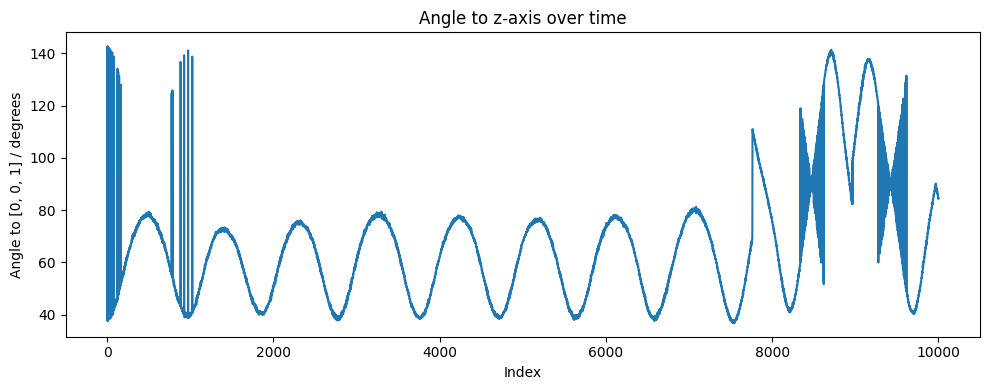

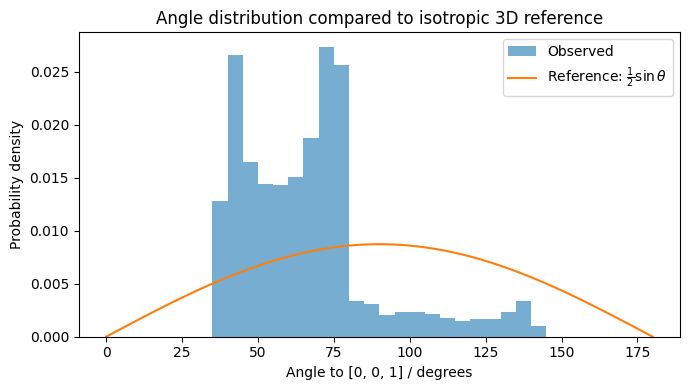

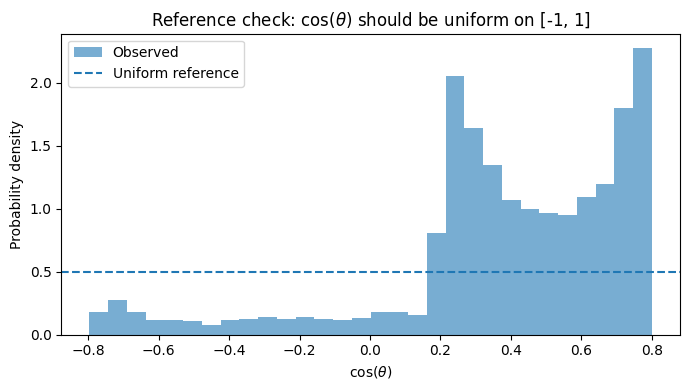

In [202]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.array(normals)

# normalize only for angular analysis
norms = np.linalg.norm(arr, axis=1)
unit = arr / norms[:, None]

cos_theta = np.clip(unit[:, 2], -1.0, 1.0)
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

# time series
plt.figure(figsize=(10, 4))
plt.plot(theta_deg)
plt.xlabel("Index")
plt.ylabel("Angle to [0, 0, 1] / degrees")
plt.title("Angle to z-axis over time")
plt.tight_layout()
plt.show()

# histogram vs reference distribution
bins = np.linspace(0, 180, 37)

plt.figure(figsize=(7, 4))
plt.hist(theta_deg, bins=bins, density=True, alpha=0.6, label="Observed")

theta_grid_deg = np.linspace(0, 180, 500)
theta_grid_rad = np.radians(theta_grid_deg)

# convert density from radians to degrees
p_theta_deg = 0.5 * np.sin(theta_grid_rad) * np.pi / 180

plt.plot(theta_grid_deg, p_theta_deg, label=r"Reference: $\frac{1}{2}\sin\theta$")

plt.xlabel("Angle to [0, 0, 1] / degrees")
plt.ylabel("Probability density")
plt.title("Angle distribution compared to isotropic 3D reference")
plt.legend()
plt.tight_layout()
plt.show()

# also useful: cos(theta) should be uniform
plt.figure(figsize=(7, 4))
plt.hist(cos_theta, bins=30, density=True, alpha=0.6, label="Observed")
plt.axhline(0.5, linestyle="--", label="Uniform reference")
plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Probability density")
plt.title(r"Reference check: $\cos(\theta)$ should be uniform on [-1, 1]")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
mol = ase.io.read(listed_files[0])
mol

In [119]:
CONFIG= "/mmhome/boittier/home/ckpts/ring_ef2_ptT_run2/config-66b8e895-abc4-4ae5-9c26-3e09c67126a2.json"
PARAMS = "/mmhome/boittier/home/ckpts/ring_ef2_ptT_run2/params-66b8e895-abc4-4ae5-9c26-3e09c67126a2.json"
EF = np.array([0,0,0.001])

In [120]:
calc = AseCalculatorEF(
    PARAMS,
    config_path=CONFIG,
    electric_field=EF,  # optional default field (model input units)
    field_scale=100,  # E_physical [au] = E_input * field_scale
)
print(calc)

In [121]:
mol.calc = calc

In [122]:
# set up optimizer
opt = BFGS(
    mol,
    trajectory="opt_bfgs.traj",   # optional: saves optimization path
    logfile="-",                  # prints progress in notebook
    maxstep=0.04,                 # conservative step size (A)
)
# run until converged
opt.run(fmax=0.003, steps=1000)
print("Converged geometry:")
print(mol.get_positions())
print("Final energy (eV):", mol.get_potential_energy())
print("Final max |F| (eV/A):", np.max(np.abs(mol.get_forces())))

      Step     Time          Energy          fmax
BFGS:    0 18:39:46      -67.359009        3.290582
BFGS:    1 18:39:46      -67.658958        1.187083
BFGS:    2 18:39:46      -67.767960        0.873524
BFGS:    3 18:39:46      -67.854691        0.823885
BFGS:    4 18:39:46      -67.928711        0.704183
BFGS:    5 18:39:46      -67.948112        0.395353
BFGS:    6 18:39:46      -67.975525        0.374971
BFGS:    7 18:39:46      -67.981812        0.344785
BFGS:    8 18:39:46      -67.992592        0.198251
BFGS:    9 18:39:46      -67.987701        0.144180
BFGS:   10 18:39:46      -67.989578        0.151328
BFGS:   11 18:39:46      -67.997780        0.167479
BFGS:   12 18:39:46      -68.003418        0.137293
BFGS:   13 18:39:46      -68.000511        0.111922
BFGS:   14 18:39:46      -68.015091        0.093500
BFGS:   15 18:39:46      -68.005043        0.094498
BFGS:   16 18:39:46      -68.007896        0.090371
BFGS:   17 18:39:46      -68.005188        0.105607
BFGS:   18 18:

In [123]:
# --- ASE NVE (Velocity Verlet): minimal example ---
import numpy as np
from ase import Atoms, units
from ase.calculators.lj import LennardJones
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation

from pathlib import Path
from ase.io.trajectory import Trajectory

rng = np.random.default_rng(7)
temperature_K = 300.0
MaxwellBoltzmannDistribution(mol, temperature_K=temperature_K, rng=rng)
# Optional: zero net drift / angular momentum (recommended for finite clusters & NVE)
Stationary(mol)
ZeroRotation(mol)
dt_fs = 0.5
dyn = VelocityVerlet(mol, timestep=dt_fs * units.fs)
E0 = mol.get_potential_energy() + mol.get_kinetic_energy()
print(f"initial E_tot (eV) ≈ {E0:.6f}")

NSTEP = 500_000
STEPSIZE = 1000

traj_path = Path("nve_test.traj")  # change as you like
with Trajectory(traj_path, mode="w") as traj:
    traj.write(mol)  # frame 0
    for step in range(0, NSTEP, STEPSIZE):
        if step > 0:
            dyn.run(STEPSIZE)
        traj.write(mol)
        #print(step, "frames written →", traj_path)
        Epot = mol.get_potential_energy()
        Ekin = mol.get_kinetic_energy()
        T = mol.get_temperature()
        print(f"step={step:4d}  E_pot={Epot:+.5f}  E_kin={Ekin:+.5f}  E_tot={Epot+Ekin:+.5f}  T(K)≈{T:.1f}")


# for step in range(0, NSTEP, log_every):
#     if step > 0:
#         dyn.run(log_every)
#     Epot = mol.get_potential_energy()
#     Ekin = mol.get_kinetic_energy()
#     T = mol.get_temperature()
#     print(f"step={step:4d}  E_pot={Epot:+.5f}  E_kin={Ekin:+.5f}  E_tot={Epot+Ekin:+.5f}  T(K)≈{T:.1f}")

initial E_tot (eV) ≈ -67.555212
step=   0  E_pot=-68.01910  E_kin=+0.46388  E_tot=-67.55521  T(K)≈239.3
step=1000  E_pot=-67.78735  E_kin=+0.23816  E_tot=-67.54919  T(K)≈122.8
step=2000  E_pot=-67.77064  E_kin=+0.22620  E_tot=-67.54444  T(K)≈116.7
step=3000  E_pot=-67.79861  E_kin=+0.25221  E_tot=-67.54640  T(K)≈130.1
step=4000  E_pot=-67.78772  E_kin=+0.23493  E_tot=-67.55279  T(K)≈121.2
step=5000  E_pot=-67.84062  E_kin=+0.28952  E_tot=-67.55110  T(K)≈149.3
step=6000  E_pot=-67.77656  E_kin=+0.22466  E_tot=-67.55190  T(K)≈115.9
step=7000  E_pot=-67.75387  E_kin=+0.20270  E_tot=-67.55116  T(K)≈104.5
step=8000  E_pot=-67.80624  E_kin=+0.26399  E_tot=-67.54225  T(K)≈136.2
step=9000  E_pot=-67.75507  E_kin=+0.21056  E_tot=-67.54450  T(K)≈108.6
step=10000  E_pot=-67.73990  E_kin=+0.19221  E_tot=-67.54768  T(K)≈99.1
step=11000  E_pot=-67.80383  E_kin=+0.25729  E_tot=-67.54654  T(K)≈132.7
step=12000  E_pot=-67.81179  E_kin=+0.25721  E_tot=-67.55458  T(K)≈132.7
step=13000  E_pot=-67.80486  E

In [124]:
from ase.io import read
from ase.io.trajectory import Trajectory
frames = read("nve_test_z.traj", ":")

In [132]:
view(frames[-1], viewer="x3d")

In [126]:
cps = []
Es = []
for _ in frames:

    
    R = _.get_positions()
    ring_idx = [0, 3, 6, 9, 12]  # your case (5-ring)
    
    cp = cp_from_R(R, ring_idx, degrees=True)
    cps.append(cp)
    Es.append(_.get_potential_energy())


In [138]:
normals = [cps[i]["normal"] for i in range(len(cps))]
np.array(normals)

array([[-0.51610149,  0.73472501,  0.44024812],
       [-0.51610149,  0.73472501,  0.44024812],
       [-0.5122498 ,  0.718702  ,  0.47017823],
       ...,
       [-0.02252431, -0.4758666 , -0.879229  ],
       [-0.54714255, -0.23760152, -0.80260859],
       [-0.94835041, -0.1655239 , -0.2706166 ]], shape=(1002, 3))

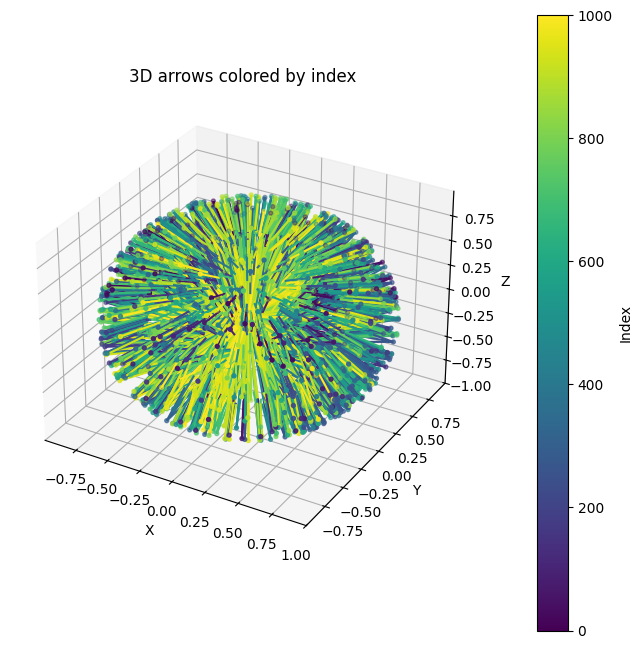

In [142]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# your array
# arr = np.array([...])   # shape (1002, 3)

# make sure it's shape (N, 3)
arr = np.array(normals)
assert arr.ndim == 2 and arr.shape[1] == 3



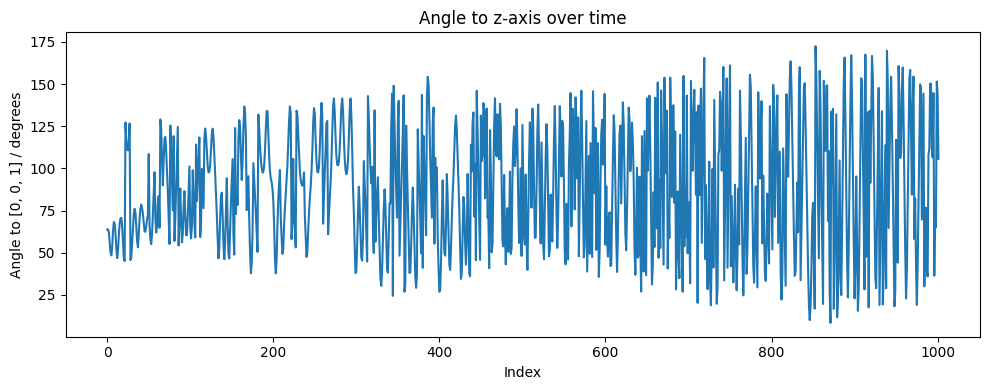

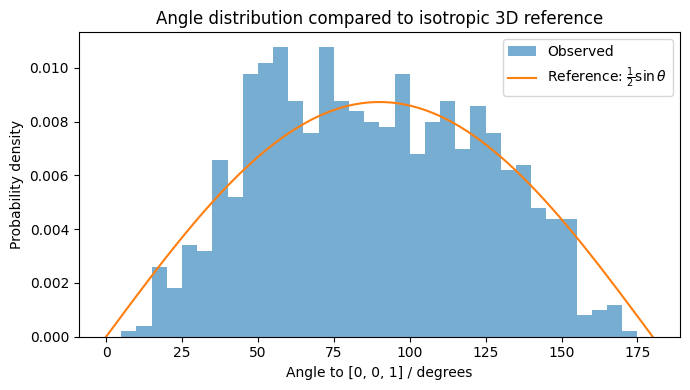

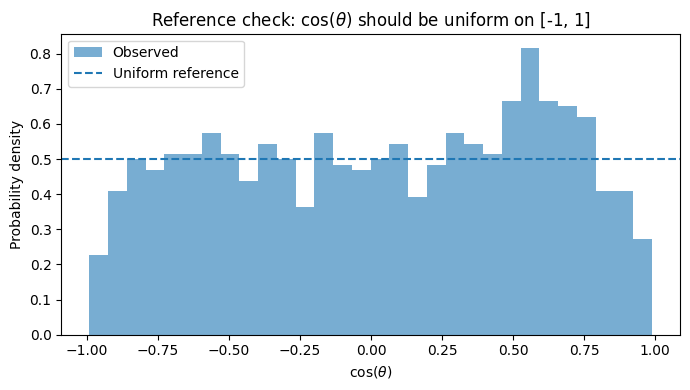

In [145]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.asarray(arr)

# normalize only for angular analysis
norms = np.linalg.norm(arr, axis=1)
unit = arr / norms[:, None]

cos_theta = np.clip(unit[:, 2], -1.0, 1.0)
theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

# time series
plt.figure(figsize=(10, 4))
plt.plot(theta_deg)
plt.xlabel("Index")
plt.ylabel("Angle to [0, 0, 1] / degrees")
plt.title("Angle to z-axis over time")
plt.tight_layout()
plt.show()

# histogram vs reference distribution
bins = np.linspace(0, 180, 37)

plt.figure(figsize=(7, 4))
plt.hist(theta_deg, bins=bins, density=True, alpha=0.6, label="Observed")

theta_grid_deg = np.linspace(0, 180, 500)
theta_grid_rad = np.radians(theta_grid_deg)

# convert density from radians to degrees
p_theta_deg = 0.5 * np.sin(theta_grid_rad) * np.pi / 180

plt.plot(theta_grid_deg, p_theta_deg, label=r"Reference: $\frac{1}{2}\sin\theta$")

plt.xlabel("Angle to [0, 0, 1] / degrees")
plt.ylabel("Probability density")
plt.title("Angle distribution compared to isotropic 3D reference")
plt.legend()
plt.tight_layout()
plt.show()

# also useful: cos(theta) should be uniform
plt.figure(figsize=(7, 4))
plt.hist(cos_theta, bins=30, density=True, alpha=0.6, label="Observed")
plt.axhline(0.5, linestyle="--", label="Uniform reference")
plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Probability density")
plt.title(r"Reference check: $\cos(\theta)$ should be uniform on [-1, 1]")
plt.legend()
plt.tight_layout()
plt.show()

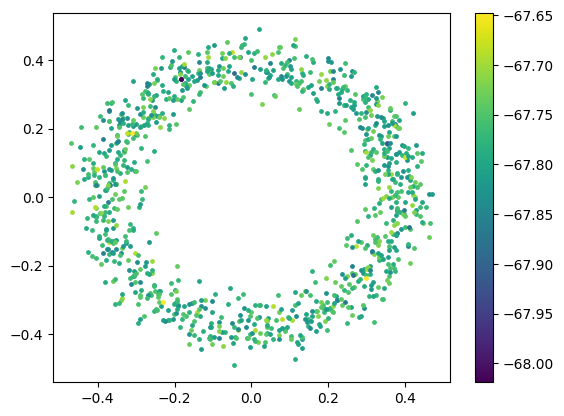

In [127]:
cps_, Es_ = [], []
for cp, E in zip(cps, Es):
    s = plt.scatter(cp["q"] * np.cos(cp["P"]), cp["q"] * np.sin(cp["P"]), s=6.0, c=E, vmin=min(Es), vmax=max(Es))
    cps_.append((cp["q"] * np.cos(cp["P"]), cp["q"] * np.sin(cp["P"])))
plt.colorbar(s)

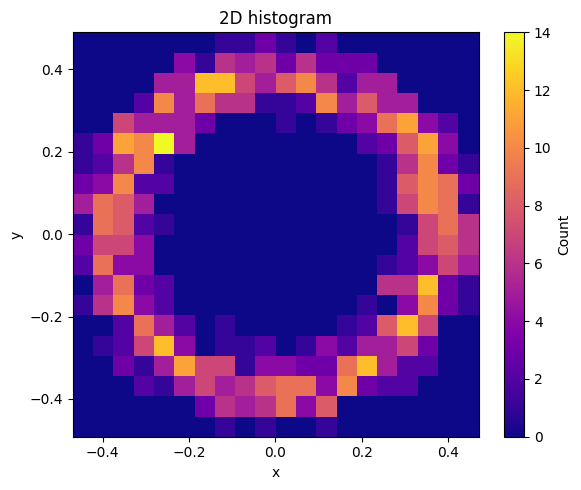

In [129]:
cps_ = np.array(cps_)
plt.figure(figsize=(6, 5))
plt.hist2d(cps_[:,0], cps_[:,1], bins=20, cmap="plasma")
plt.colorbar(label="Count")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D histogram")
plt.tight_layout()
plt.show()

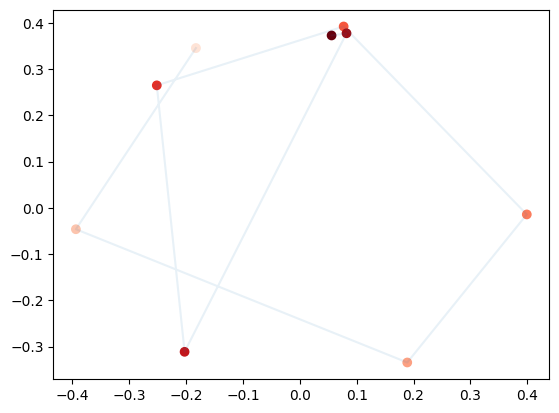

In [131]:
N = 10
plt.plot(cps_[:N,0], cps_[:N,1], alpha=.1)
plt.scatter(cps_[:N,0], cps_[:N,1], c=range(N), cmap="Reds")

In [ ]:
cps_ = np.array(cps_)
plt.figure(figsize=(6, 5))
plt.hist2d(cps_[:,0], cps_[:,1], bins=20, cmap="plasma")
plt.colorbar(label="Count")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D histogram")
plt.tight_layout()
plt.show()

In [39]:
data_files = list(Path(samples_dir).glob("*.h5"))

In [40]:
data_files

[PosixPath('qP_samples/q_0.500_P_0.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_108.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_126.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_144.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_162.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_180.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_18.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_198.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_216.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_234.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_252.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_270.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_288.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_306.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_324.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_342.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_36.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_54.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_72.0.xyz.h5'),
 PosixPath('qP_samples/q_0.500_P_90.0.xyz.h5')]

In [7]:
import h5py

out_data_set = {}

for filename in data_files:
    out_data = {}
    with h5py.File(filename, "r") as f:
        # Print all root level object names (aka keys) 
        # these can be group or dataset names 
        print("Keys: %s" % f.keys())
        # get first object name/key; may or may NOT be a group
        for a_group_key in list(f.keys()):
            try:
                # get the object type for a_group_key: usually group or dataset
                print(type(f[a_group_key])) 
            
                # # If a_group_key is a group name, 
                # # this gets the object names in the group and returns as a list
                # data = list(f[a_group_key])
            
                # If a_group_key is a dataset name, 
                # this gets the dataset values and returns as a list
                # data = list(f[a_group_key])
                # preferred methods to get dataset values:
                ds_obj = f[a_group_key]      # returns as a h5py dataset object
                ds_arr = f[a_group_key][()]  # returns as a numpy array
                out_data[a_group_key] = ds_arr
            except:
                pass
    out_data_set[str(filename)] = out_data

Keys: <KeysViewHDF5 ['N', 'R', 'Z', 'energy', 'gradient', 'harmonic', 'hessian', 'thermo']>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.group.Group'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.group.Group'>
Keys: <KeysViewHDF5 ['N', 'R', 'Z', 'energy', 'gradient', 'harmonic', 'hessian', 'thermo']>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.group.Group'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.group.Group'>
Keys: <KeysViewHDF5 ['N', 'R', 'Z', 'energy', 'gradient', 'harmonic', 'hessian', 'thermo']>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<class 'h5py._hl.dataset.Dataset'>
<clas

In [8]:
out_data_set.keys()

dict_keys(['qP_samples/q_0.000_P_0.0.xyz.h5', 'qP_samples/q_0.000_P_108.0.xyz.h5', 'qP_samples/q_0.000_P_126.0.xyz.h5', 'qP_samples/q_0.000_P_144.0.xyz.h5', 'qP_samples/q_0.000_P_162.0.xyz.h5', 'qP_samples/q_0.000_P_180.0.xyz.h5', 'qP_samples/q_0.000_P_18.0.xyz.h5', 'qP_samples/q_0.000_P_198.0.xyz.h5', 'qP_samples/q_0.000_P_216.0.xyz.h5', 'qP_samples/q_0.000_P_234.0.xyz.h5', 'qP_samples/q_0.000_P_252.0.xyz.h5', 'qP_samples/q_0.000_P_270.0.xyz.h5', 'qP_samples/q_0.000_P_288.0.xyz.h5', 'qP_samples/q_0.000_P_306.0.xyz.h5', 'qP_samples/q_0.000_P_324.0.xyz.h5', 'qP_samples/q_0.000_P_342.0.xyz.h5', 'qP_samples/q_0.000_P_36.0.xyz.h5', 'qP_samples/q_0.000_P_54.0.xyz.h5', 'qP_samples/q_0.000_P_72.0.xyz.h5', 'qP_samples/q_0.000_P_90.0.xyz.h5', 'qP_samples/q_0.100_P_0.0.xyz.h5', 'qP_samples/q_0.100_P_108.0.xyz.h5', 'qP_samples/q_0.100_P_126.0.xyz.h5', 'qP_samples/q_0.100_P_144.0.xyz.h5', 'qP_samples/q_0.100_P_162.0.xyz.h5', 'qP_samples/q_0.100_P_180.0.xyz.h5', 'qP_samples/q_0.100_P_18.0.xyz.h5', 

In [9]:
p = [float(_.split("_")[2]) for _ in out_data_set.keys()]
q = [float(_.split("_")[4][:-7]) for _ in out_data_set.keys()]
p[0], q[0]

(0.0, 0.0)

In [10]:
import pandas as pd
import numpy as np
df = pd.DataFrame(out_data_set).T
np.mgrid?

Type:        MGridClass
String form: <numpy.lib._index_tricks_impl.MGridClass object at 0x150a40713400>
File:        ~/.local/lib/python3.12/site-packages/numpy/lib/_index_tricks_impl.py
Docstring:  
An instance which returns a dense multi-dimensional "meshgrid".

An instance which returns a dense (or fleshed out) mesh-grid
when indexed, so that each returned argument has the same shape.
The dimensions and number of the output arrays are equal to the
number of indexing dimensions.  If the step length is not a complex
number, then the stop is not inclusive.

However, if the step length is a **complex number** (e.g. 5j), then
the integer part of its magnitude is interpreted as specifying the
number of points to create between the start and stop values, where
the stop value **is inclusive**.

Returns
-------
mesh-grid : ndarray
    A single array, containing a set of `ndarray`\ s all of the same
    dimensions. stacked along the first axis.

See Also
--------
ogrid : like `mgrid` but retu

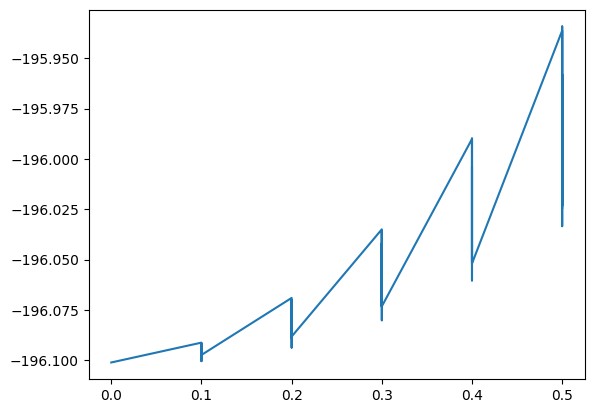

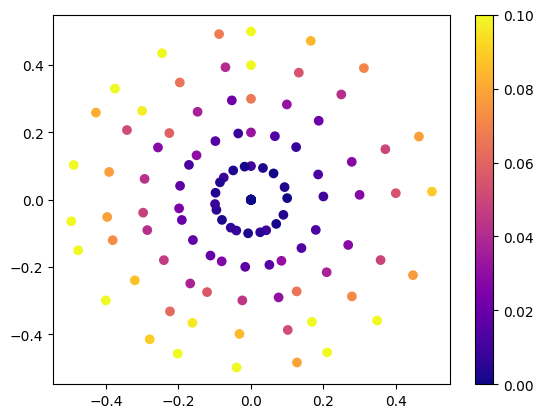

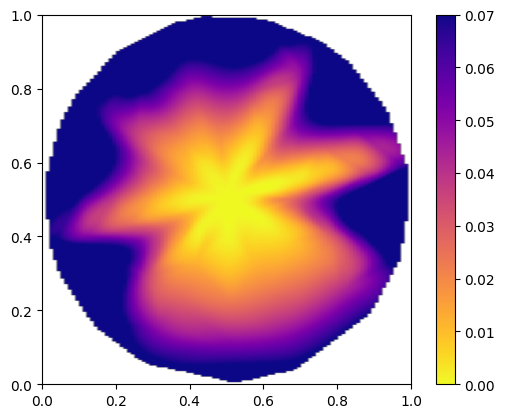

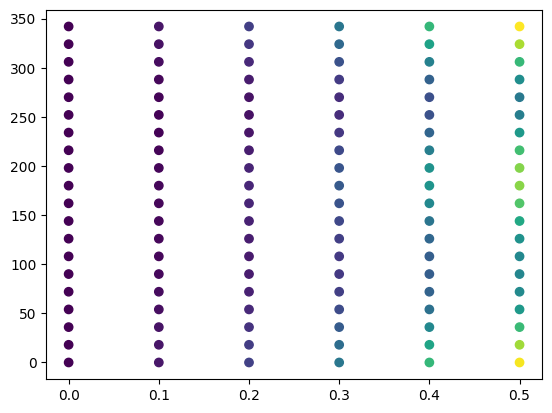

In [13]:
df['p'] = p
df['q'] = q

grid_x, grid_y = np.mgrid[-0.5:0.5:100j, -0.5:0.5:200j]

plt.plot(p, df["energy"])
plt.show()
s = plt.scatter(p * np.sin(q), p * np.cos(q), c=df["energy"] - df["energy"].min(), vmin=0, vmax=.1, cmap="plasma")
plt.colorbar(s)
plt.show()
from scipy.interpolate import griddata
# gd = griddata()
grid_z2 = griddata(np.array([(a,b) for a,b in zip(p * np.cos(q), p * -np.sin(q))]), df["energy"] - df["energy"].min(), (grid_x, grid_y),
                   method='cubic')

plt.imshow(grid_z2.T, extent=(0,1,0,1), origin='lower', vmin=0, vmax=.07, cmap="plasma_r")
plt.colorbar()

plt.show()
plt.scatter(p, q, c=df["energy"])

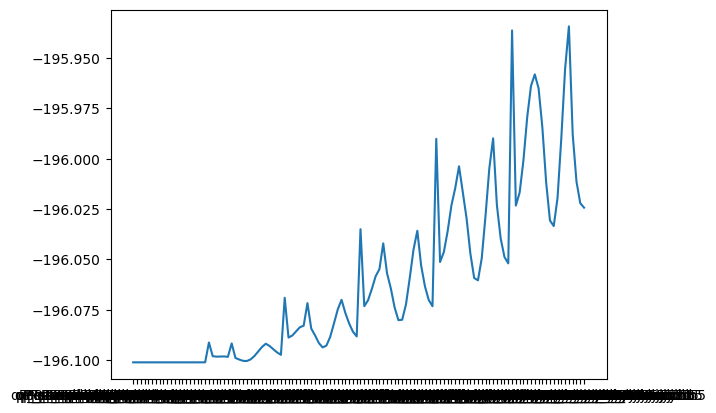

In [14]:


plt.plot(df["energy"])

In [15]:
ds_obj

<Closed HDF5 group>

In [16]:
out_data

{'N': np.int64(15),
 'R': array([[ 1.7343201 ,  1.28622879,  0.37682143],
        [ 2.54311607,  1.33404689, -0.36683861],
        [ 1.95658571,  2.06280899,  1.1254041 ],
        [ 0.49144724,  1.40229525, -0.47707598],
        [ 0.09184007,  0.94538537, -1.39813279],
        [ 0.56357284,  2.48101081, -0.66967596],
        [-0.58217212,  0.50695597,  0.25457176],
        [-1.0035127 ,  1.31764223,  0.87272608],
        [-1.42472644,  0.02551891, -0.25864514],
        [ 0.37102801, -0.71946079,  0.70391663],
        [-0.29298237, -1.35743771,  1.30066989],
        [ 0.99660435, -1.39364687,  0.0935053 ],
        [ 1.57164042,  0.10640135,  1.30896287],
        [ 2.63347494, -0.17201575,  1.33536115],
        [ 1.19424669, -0.00985641,  2.33945783]]),
 'Z': array([6, 1, 1, 6, 1, 1, 6, 1, 1, 6, 1, 1, 6, 1, 1], dtype=int32),
 'energy': np.float64(-196.02429100285195),
 'gradient': array([[ 6.87415955e-03,  1.23258703e-03, -3.79036306e-03],
        [-1.70473314e-02,  1.68003110e-02, -1.22

In [18]:
fs = Path("qP_samples/").glob("*_ef0.npz")
cps = []
Es = []
for _ in fs:
    data = np.load(_)
    
    R = data["R"]
    
    ring_idx = [0, 3, 6, 9, 12]  # your case (5-ring)
    
    cp = cp_from_R(R, ring_idx, degrees=True)
    cps.append(cp)
    Es.append(data["E"])

# "qP_samples/q_0.100_P_288.0.xyz.h5.npz_ef0.npz"


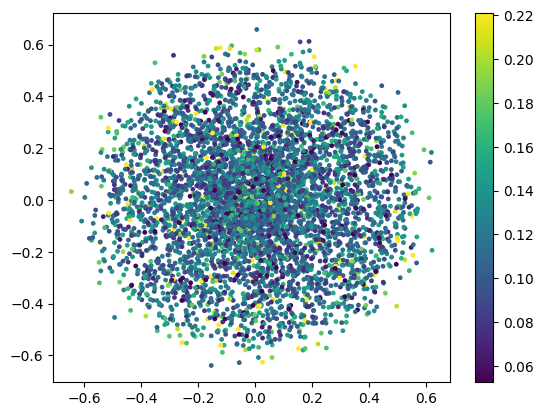

In [27]:
cps_, Es_ = [], []
for cp, E in zip(cps, Es):
    for _ in zip(cp["q"], cp["P"]):
        cps_.append(_)
    for _ in E:
        Es_.append(_)
    s = plt.scatter(cp["q"] * np.cos(cp["P"]), cp["q"] * np.sin(cp["P"]), s=6.0, c=E + 196.08)

plt.colorbar(s)

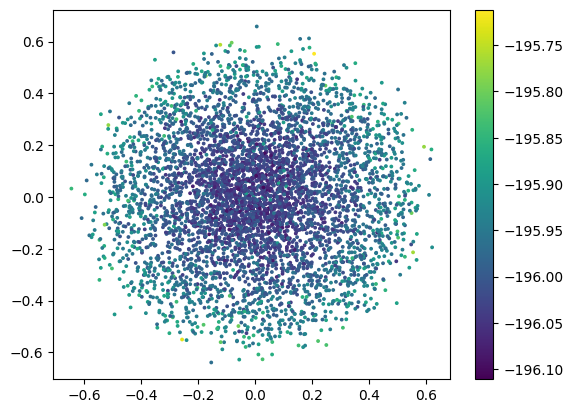

In [50]:
# plt.scatter(, c=Es_)
a,b = np.array(cps_).T
x_cp = a * np.cos(b)
y_cp = a * np.sin(b)
s = plt.scatter(x_cp, y_cp, c=Es_,s=3)
plt.colorbar(s)

In [45]:
# np.array(cps_), np.array(Es_)
np.stack([x_cp, y_cp]).T.shape

(6000, 2)

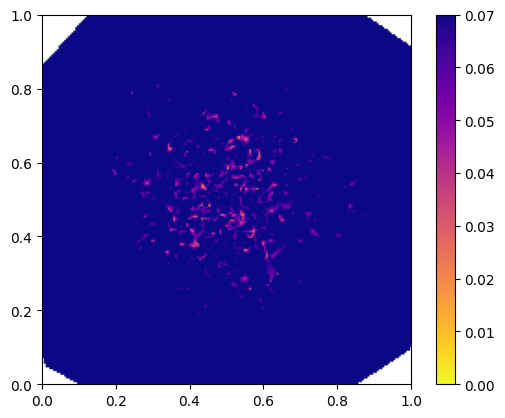

In [49]:
grid_x, grid_y = np.mgrid[-0.5:0.5:200j, -0.5:0.5:200j]

grid_z2 = griddata(np.stack([x_cp, y_cp]).T, np.array(Es_) - np.array(Es_).min(), (grid_x, grid_y),
                   method='linear')

plt.imshow(grid_z2.T, extent=(0,1,0,1), origin='lower', vmin=0, vmax=.07, cmap="plasma_r")
plt.colorbar()

In [30]:
data.keys()

KeysView(NpzFile 'qP_samples/q_0.500_P_90.0.xyz.h5.npz_ef0.npz' with keys: R, Z, N, Ef, E...)

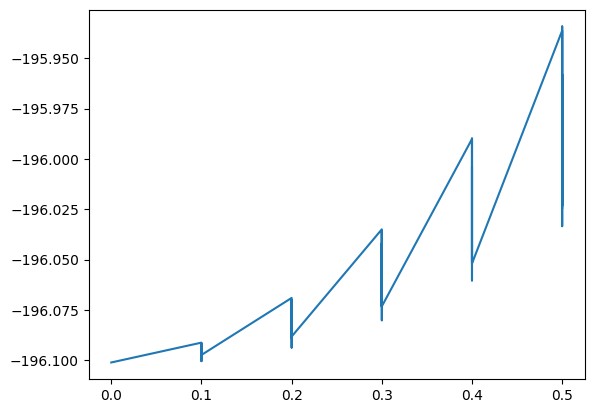

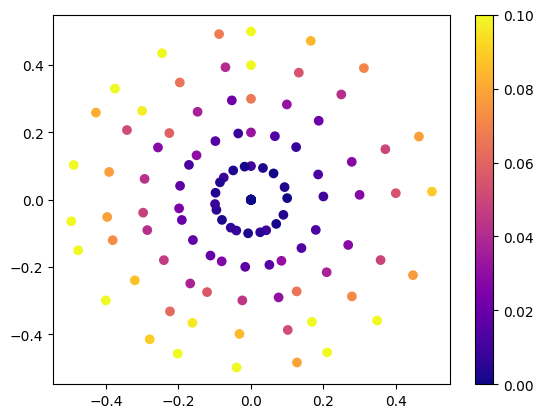

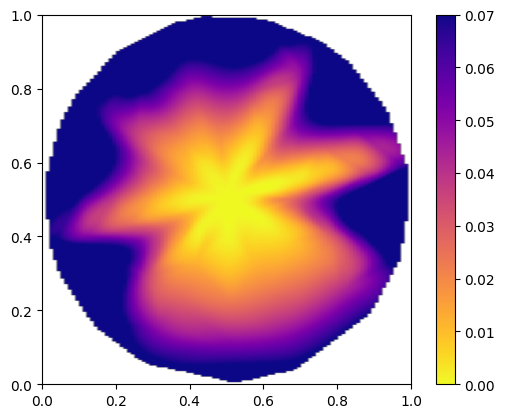

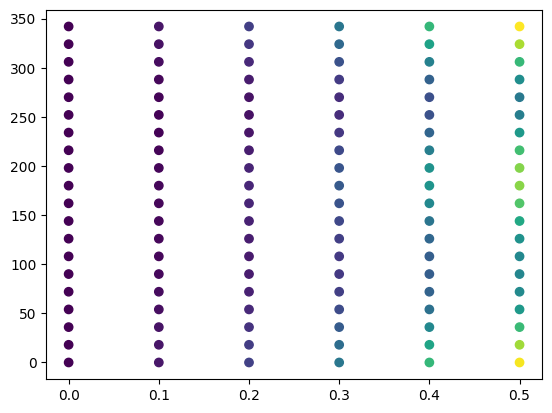

In [31]:
df['p'] = p
df['q'] = q

grid_x, grid_y = np.mgrid[-0.5:0.5:100j, -0.5:0.5:200j]

plt.plot(p, df["energy"])
plt.show()
s = plt.scatter(p * np.sin(q), p * np.cos(q), c=df["energy"] - df["energy"].min(), vmin=0, vmax=.1, cmap="plasma")
plt.colorbar(s)
plt.show()
from scipy.interpolate import griddata
# gd = griddata()
grid_z2 = griddata(np.array([(a,b) for a,b in zip(p * np.cos(q), p * -np.sin(q))]), df["energy"] - df["energy"].min(), (grid_x, grid_y),
                   method='cubic')

plt.imshow(grid_z2.T, extent=(0,1,0,1), origin='lower', vmin=0, vmax=.07, cmap="plasma_r")
plt.colorbar()

plt.show()
plt.scatter(p, q, c=df["energy"])